In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# get dataset with unique id
dataset = fetch_ucirepo(id=468)

In [4]:
# build the dataframe by combining target and features
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)

In [5]:
# print the first few rows
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

#### Here is a description of all the features and the target:

**1.Administrative (Integer):** This is a Numerical variable. It indicates the number of administrative/account management pages visited (e.g., login, checkout page, account settings)

**2.Administrative_Duration (Continuous):** It is a numerical feature, and it refers to the total time (in seconds) spent on administrative pages.

**3.Informational (Integer):** It is a numerical feature, and it refers to the number of informational pages visited (e.g., "About Us", contact, terms of service).

**4.Informational_Duration (Continuous):** It is a numerical feature, and it refers to the total time (in seconds) spent on informational pages.

**5.ProductRelated (Integer):** It is a numerical feature, and it refers to the number of product-related pages visited (e.g., viewing actual inventory, product details, add-to-cart pages).

**6.ProductRelated_Duration (Continuous):** It is a numerical feature, and it refers to the total time (in seconds) spent on product pages. Note: For high-intent buyers, this number is usually very high.

**7.BounceRates (Continuous):** Bounce rate is the percentage of visitors who enter the site from that specific page and immediately exit ("bounce") without triggering any other actions. So this feature refers to the average historical bounce rate of all the unique pages the user visited during this session.

**8.ExitRates (Continuous):** Exit Rate is the percentage of pageviews on a page that ended up being the last view in the session. So this feature refers to the average historical exit rate of all the unique pages the user visited during this session.

**9.PageValues (Continuous):** Page Value is the average monetary value of the page. Thus, this feature refers to the average financial value of all the unique pages the user visited during this session (calculated based on historical purchase paths)

**10.SpecialDay (Continuous, 0.0 to 1.0):** It indicates how close the session date is to a major shopping event (e.g., Mother's Day, Valentine's Day). For instance, if Valentine's Day is Feb 14th, this value peaks at 1.0 on Feb 8th (accounting for shipping/delivery times) and drops to 0.0 after.

**11.Month (Categorical):** The month of the session (Jan to Dec).

**12.Weekend (Boolean):** Whether the session occurred on a Saturday or Sunday (True or False).

**13.Operating Systems (Integer placeholder, e.g., 1, 2, 3):** Categorical representation of the OS they used (e.g., Windows, macOS, iOS).

**14.Browser (Integer placeholder):** Categorical representation of the browser they used (e.g., Chrome, Safari, Firefox).

**15.Region (Integer placeholder):** Anonymized geographic location identifier of the user.

**16.TrafficType (Integer placeholder):** How the user found the website (e.g., Direct, Paid Ad, Organic Search, Affiliate).

**17.VisitorType (Categorical):** Whether they are a New_Visitor, Returning_Visitor, or Other.

**18.Revenue (Target)** This is our target variable, and it indicates if the session ended in a purchase from the website.

In [7]:
# separate numerical and categorical features
target = "Revenue"
numerical_features = df.select_dtypes(["int64", "float64"]).columns.to_list()
categorical_features = df.select_dtypes(["object", "bool"]).columns.drop([target]).to_list()

In [8]:
print(f"Here are the categorical features : {categorical_features}\n")
print(f"These are the numerical features :  {numerical_features}\n")
print(f"Target variable : {target}")

Here are the categorical features : ['Month', 'VisitorType', 'Weekend']

These are the numerical features :  ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Target variable : Revenue


### EDA
- Now we will perform EDA on this dataset

In [9]:
def summarize_feature(df, column):
    frequency = df[column].value_counts()
    percentage = df[column].value_counts(normalize=True)

    result = pd.concat([frequency, percentage], axis=1)
    result.columns = ["Frequency", "Percentage"]
    result = result.sort_values(by="Frequency")

    format_result = (result
        .style
        .set_properties(**{'text-align': 'right'})
        .set_table_styles([
            {'selector': 'th.col_heading', 'props': [('text-align', 'left')]},
            {'selector': 'th.row_heading, td.row_heading', 'props': [('text-align', 'left')]},
        ]).format("{:.2f}"))
        
        
    return format_result


def multi_barcharts(df, features, sort=False):
    """
    Function to create bar charts for
    all categorical features together
    """

    n = len(features)
    cols = 2
    rows = math.ceil(n /cols)

    fig, axes = plt.subplots(rows, cols, figsize=(20, 4*rows))
    axes = axes.flatten()


    for i, col in enumerate(features):
        counts = df[col].value_counts(normalize=True)
        
        if sort:
            counts = counts.sort_values()
            

        axes[i].bar(x=counts.index.astype('str'), \
                    height=counts.values, color='steelblue')
        axes[i].set_title(f"Bar chart for {col}")
        axes[i].tick_params(axis='x')


    for j in range((i+1), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


def create_barchart(df, feature):

    counts = df[feature].value_counts()

    plt.figure(figsize=(10, 8))

    plt.bar(x=counts.index.astype('str'), height=counts.values, color='steelblue')
    plt.title(f"Distribution for {feature}")
    plt.tight_layout()
    plt.show()

def create_histplot_and_boxplots(df, feature):

    rows = 2
    cols = 1

    fig, axes = plt.subplots(rows, cols, figsize=(10, 8))
    data = df[feature]

    # histplot
    sns.histplot(x=data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f"Hisogram for {feature}")

    # boxplot
    sns.boxplot(x=data, ax=axes[1], color='steelblue')
    axes[1].set_title(f"Boxplot for {feature}")

    plt.tight_layout()
    plt.show()


def plot_crosstab_heatmap(df, feature, target):
    # Calculate row-normalized percentages
    ct = pd.crosstab(df[feature], df[target], normalize='index') * 100
    
    plt.figure(figsize=(8, 5))
    sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': 'Percentage (%)'})
    
    plt.title(f"Target Distribution within {feature}")
    plt.ylabel(feature)
    plt.xlabel(target)
    plt.show()
    

def numer_vs_target_side_by_side(df, numeric_feature, target):
    """
    Plots the distribution of a numerical feature in side-by-side subplots,
    with one subplot for each unique class in the target variable.
    """
    # Get unique classes sorted so the layout remains consistent
    unique_classes = sorted(df[target].dropna().unique())
    n_classes = len(unique_classes)
    
    if n_classes == 0:
        print("No target classes found.")
        return

    # Set up a 1-row grid with columns matching the number of classes
    fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5), squeeze=False)
    axes = axes.flatten()

    for i, cls in enumerate(unique_classes):
        # Filter data for the specific class
        class_data = df[df[target] == cls]
        
        # Plot the histogram + KDE onto its designated axis
        sns.histplot(
            data=class_data, 
            x=numeric_feature, 
            kde=True, 
            color='steelblue', 
            ax=axes[i]
        )
        
        # Customize the individual subplot titles and labels
        axes[i].set_title(f"Class: {cls} (n={len(class_data)})")
        axes[i].set_xlabel(numeric_feature)
        axes[i].set_ylabel("Count")

    plt.suptitle(f"Side-by-Side Distribution of {numeric_feature} across {target}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


def target_bar_charts(df, feature, target):
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=feature, hue=target, palette='Blues')
    plt.title(f'Raw Counts of Target Classes across {feature} Categories')
    plt.xlabel(f'{feature} Categories')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [10]:
# let us examine the distribution of numeric features
df[numerical_features].describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


## 1. EDA
- Next, I want to check the bar plot for categorical variables.
- Histograms and box plots for numerical variables
- distribution plots for numeric across target categories
- check distribution of target w.r.t. categorical variable

### 2. data cleaning 
- check duplicates
- missing values/ inconsistent values
- imputation
- outlier detection and handling

### 3. data transformation
- feature scaling/normalization


### 4. data modeling 

- Apply multiple ensemble decision tree models as base models
- use n different seeds
- calculate OOF predictions
- select top 10 models with best scores (based on performance criteria)
- Use NN as meta model on OOF predictions




### 1. Single variable EDA

Some of the columns with datatype as non-float seem to be categorical in nature; we will examine the unqie values in these columns:unique

In [11]:
# Next we will check the unique values in different columns
unique_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType']
print(unique_cols)

['OperatingSystems', 'Browser', 'Region', 'TrafficType']


Summary for feature 'OperatingSystems':


,Frequency,Percentage
OperatingSystems,,
5,6.00,0.00
7,7.00,0.00
6,19.00,0.00
8,79.00,0.01
4,478.00,0.04
3,2555.00,0.21
1,2585.00,0.21
2,6601.00,0.54


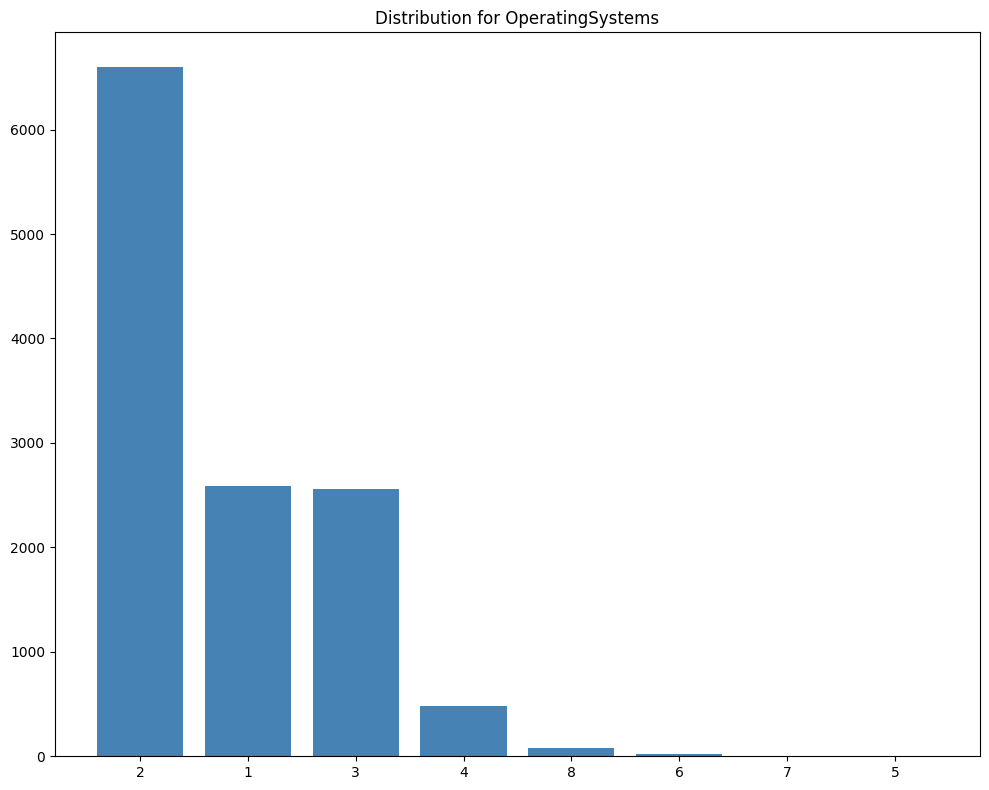



Summary for feature 'Browser':


,Frequency,Percentage
Browser,,
9,1.00,0.00
11,6.00,0.00
12,10.00,0.00
7,49.00,0.00
13,61.00,0.00
3,105.00,0.01
8,135.00,0.01
10,163.00,0.01
6,174.00,0.01


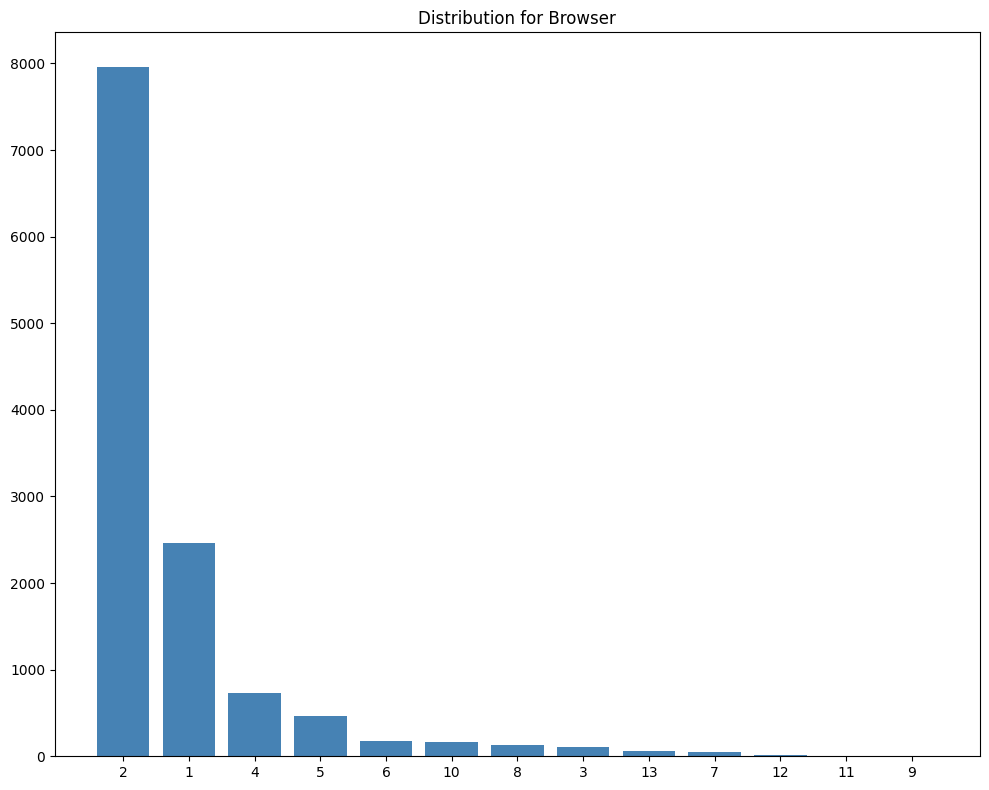



Summary for feature 'Region':


,Frequency,Percentage
Region,,
5,318.00,0.03
8,434.00,0.04
9,511.00,0.04
7,761.00,0.06
6,805.00,0.07
2,1136.00,0.09
4,1182.00,0.10
3,2403.00,0.19
1,4780.00,0.39


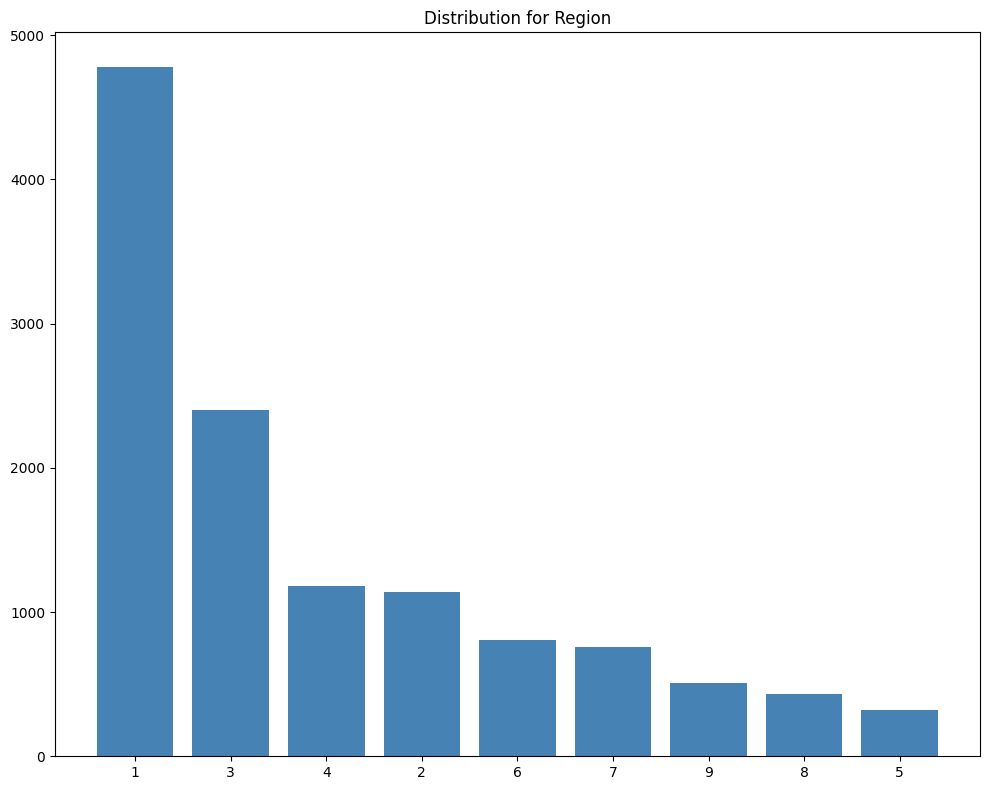



Summary for feature 'TrafficType':


,Frequency,Percentage
TrafficType,,
17,1.00,0.00
12,1.00,0.00
16,3.00,0.00
18,10.00,0.00
14,13.00,0.00
19,17.00,0.00
15,38.00,0.00
7,40.00,0.00
9,42.00,0.00


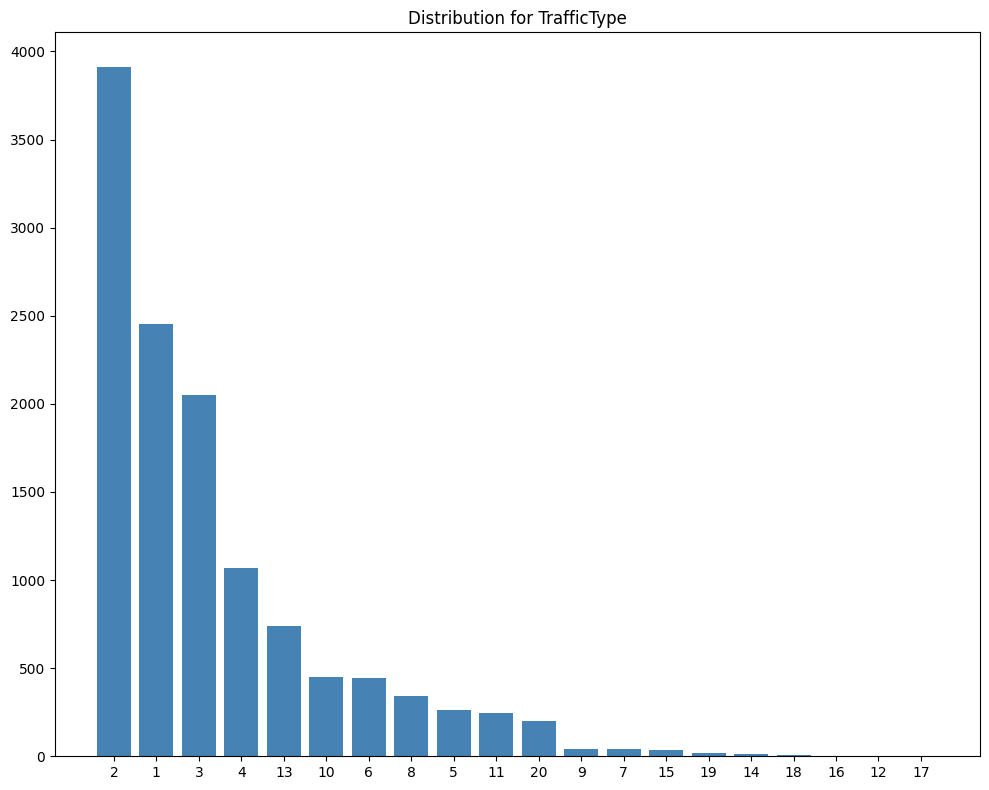



Summary for feature 'Month':


,Frequency,Percentage
Month,,
Feb,184.00,0.01
June,288.00,0.02
Jul,432.00,0.04
Aug,433.00,0.04
Sep,448.00,0.04
Oct,549.00,0.04
Dec,1727.00,0.14
Mar,1907.00,0.15
Nov,2998.00,0.24


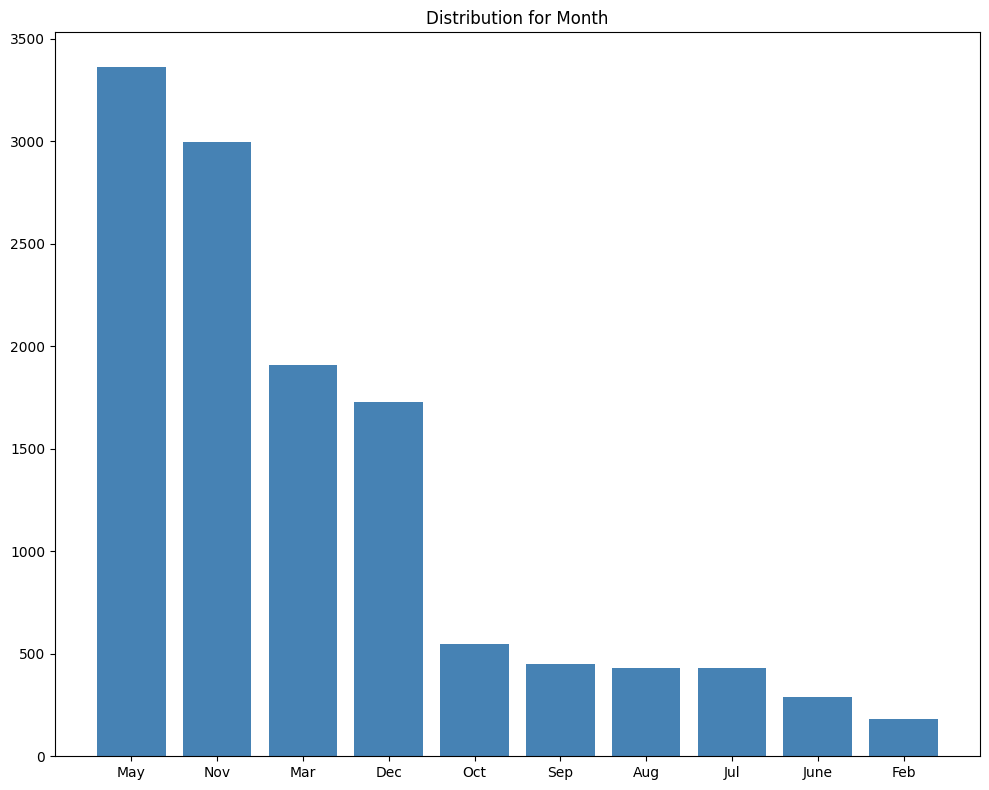



Summary for feature 'VisitorType':


,Frequency,Percentage
VisitorType,,
Other,85.00,0.01
New_Visitor,1694.00,0.14
Returning_Visitor,10551.00,0.86


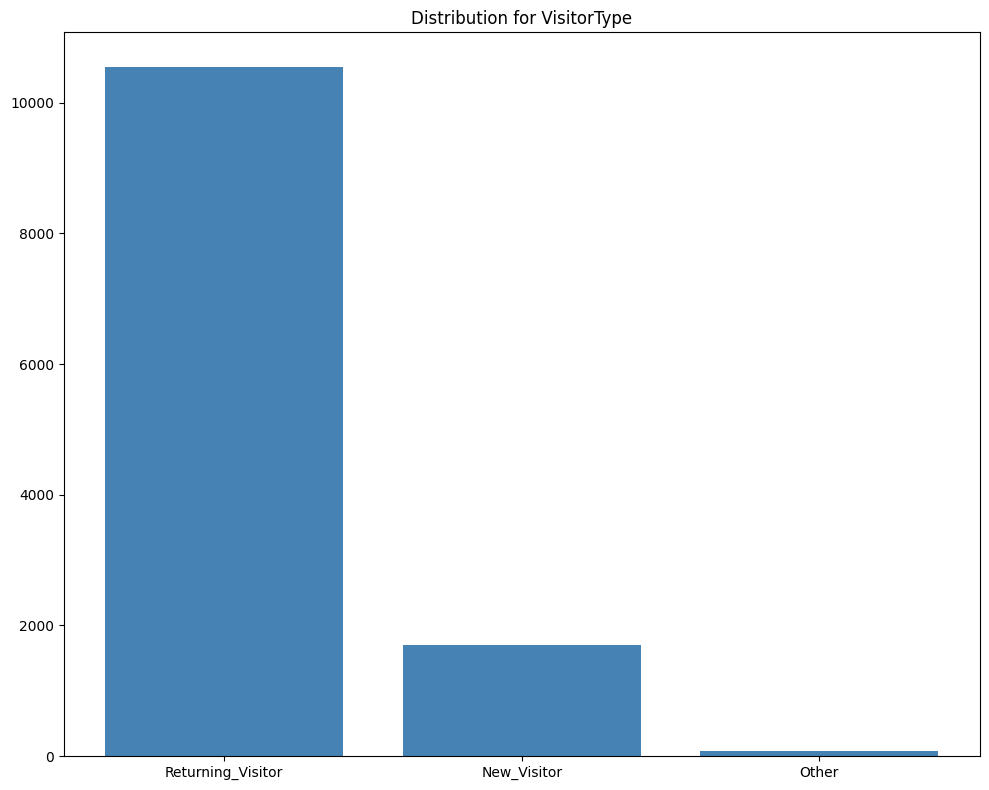



Summary for feature 'Weekend':


,Frequency,Percentage
Weekend,,
True,2868.00,0.23
False,9462.00,0.77


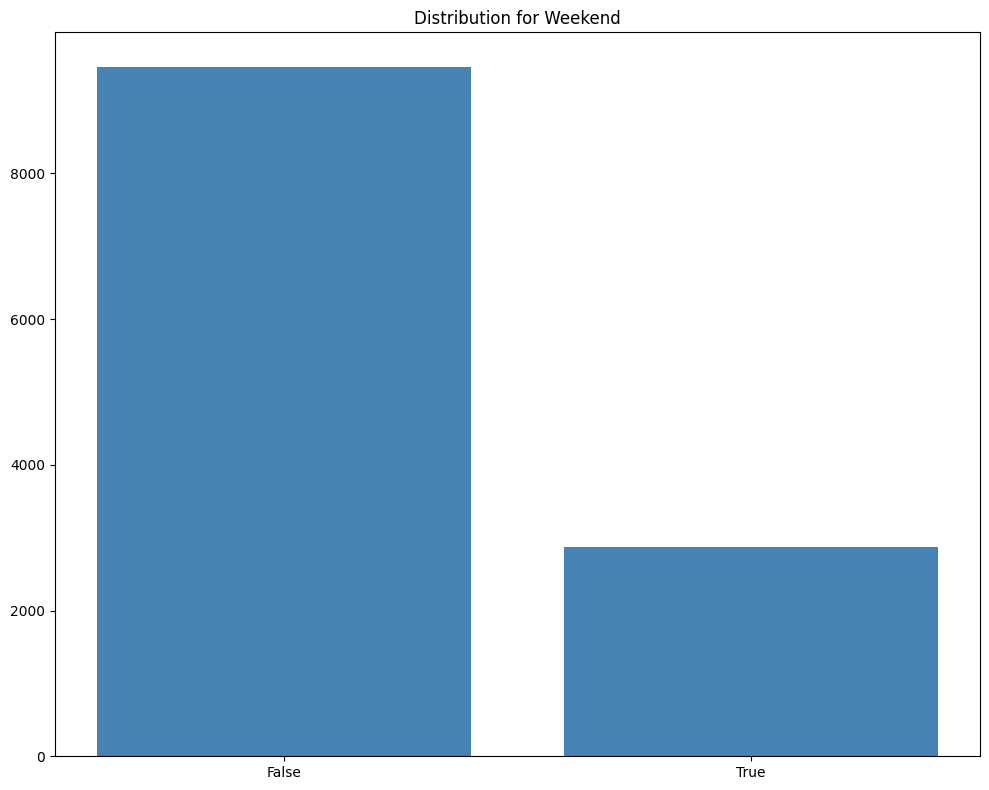

In [12]:
for col in (unique_cols + categorical_features):
    print(f"Summary for feature '{col}':")
    display(summarize_feature (df, col))
    create_barchart(df, col)
    print("\n")
    

Since, some numerical features are categorical in nature but only coded as int type, we will update our set of numerical features:

***Distribution plots for Administrative***


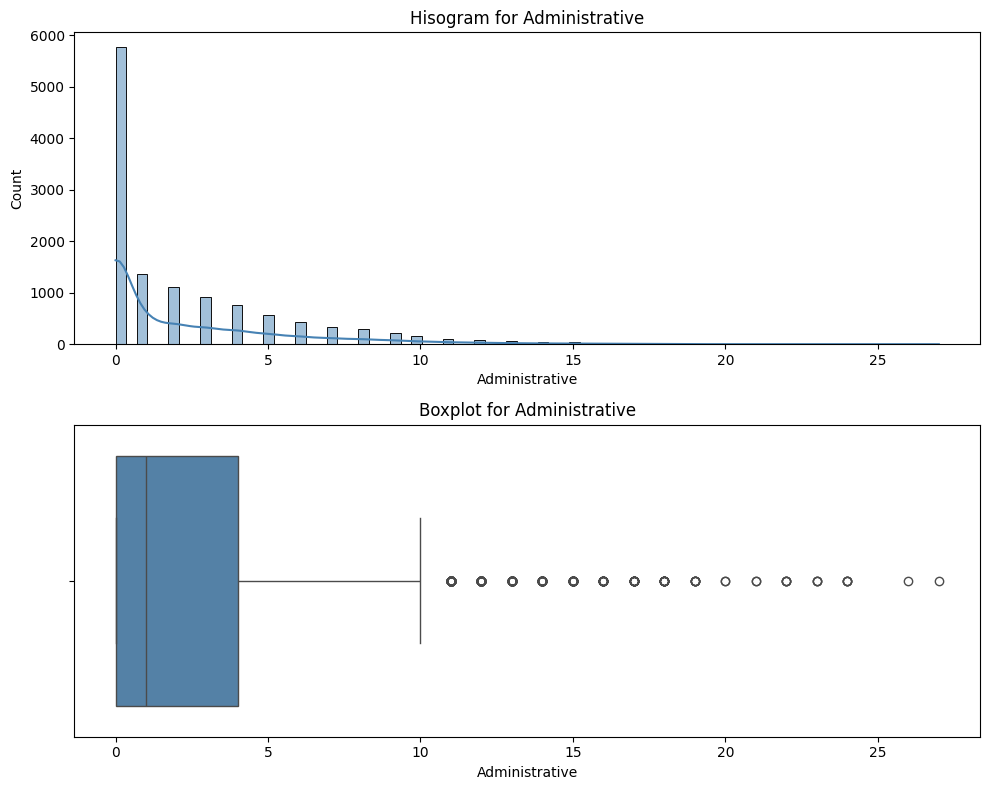



***Distribution plots for Administrative_Duration***


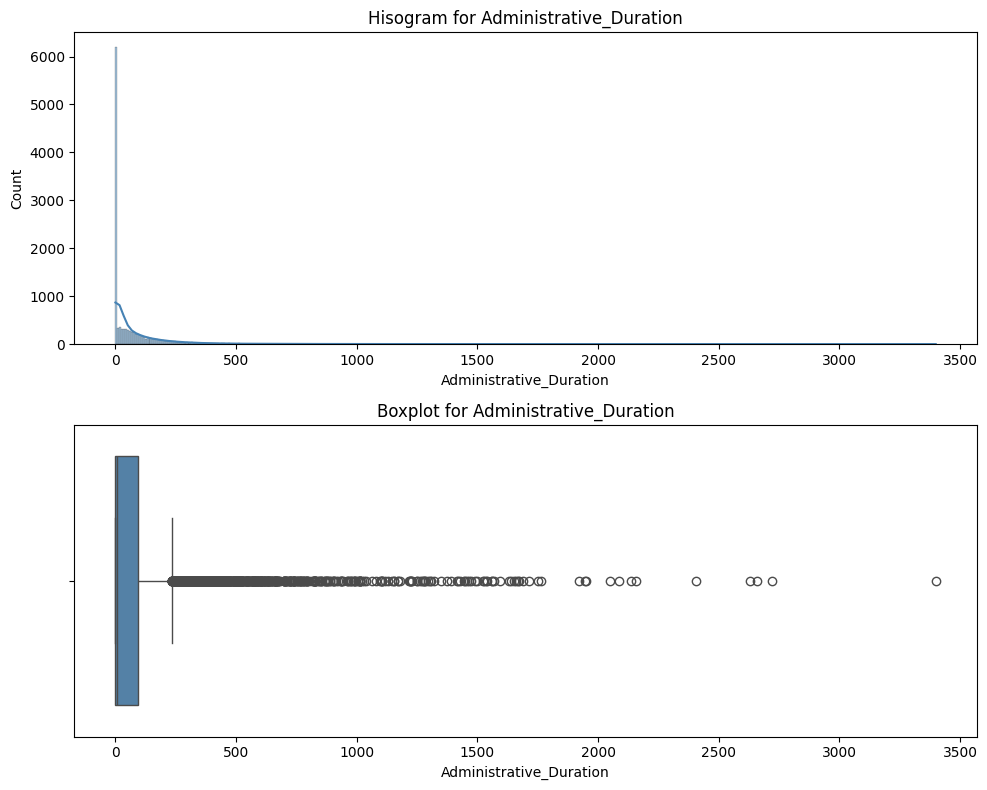



***Distribution plots for Informational***


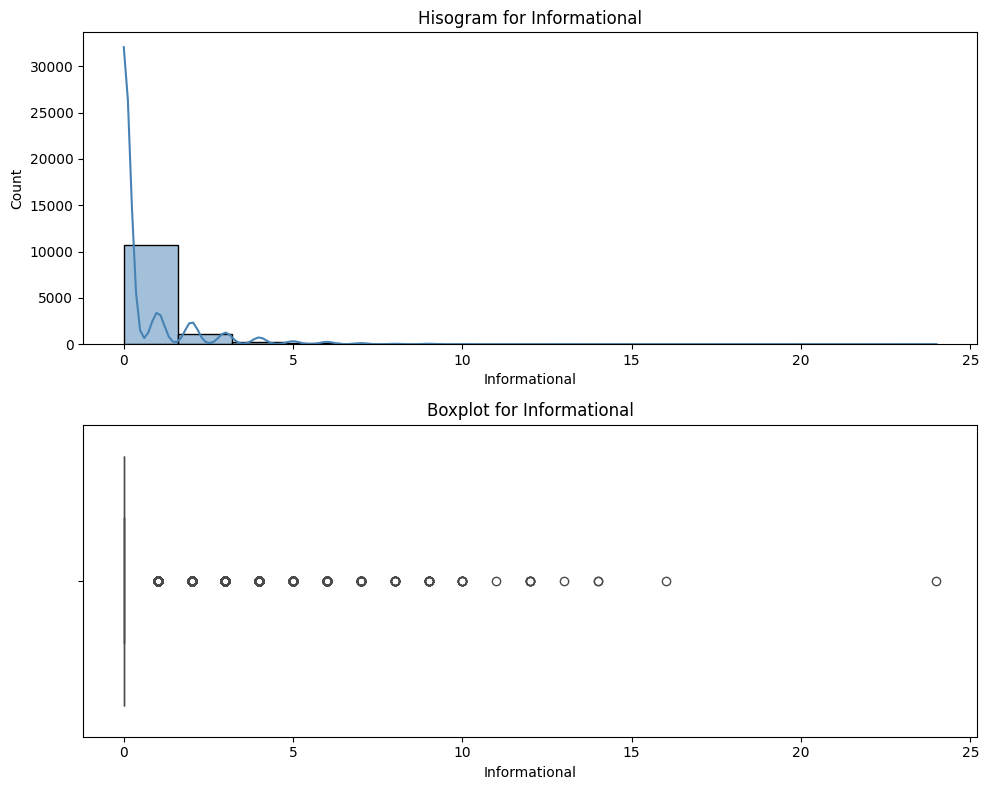



***Distribution plots for Informational_Duration***


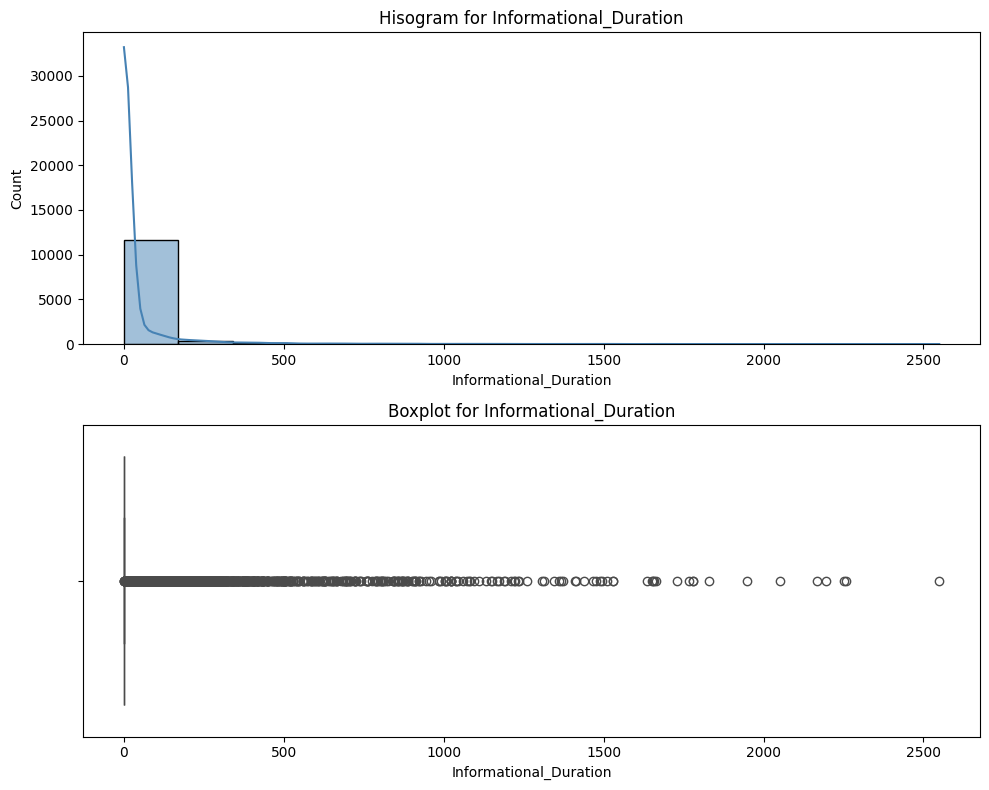



***Distribution plots for ProductRelated***


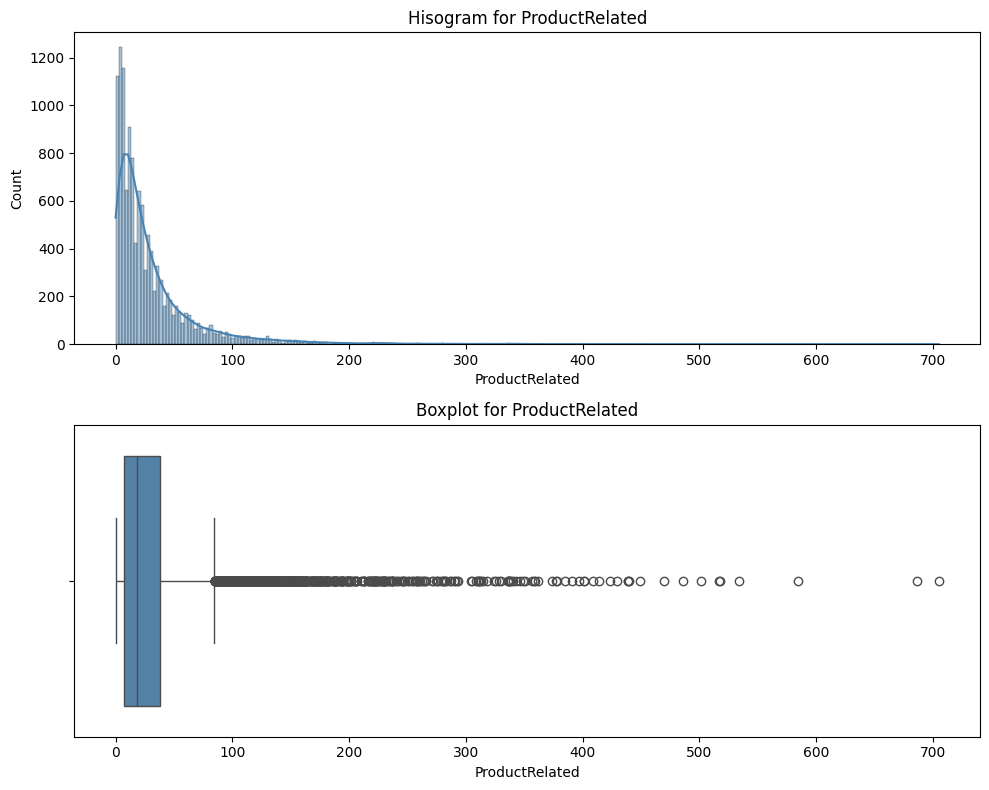



***Distribution plots for ProductRelated_Duration***


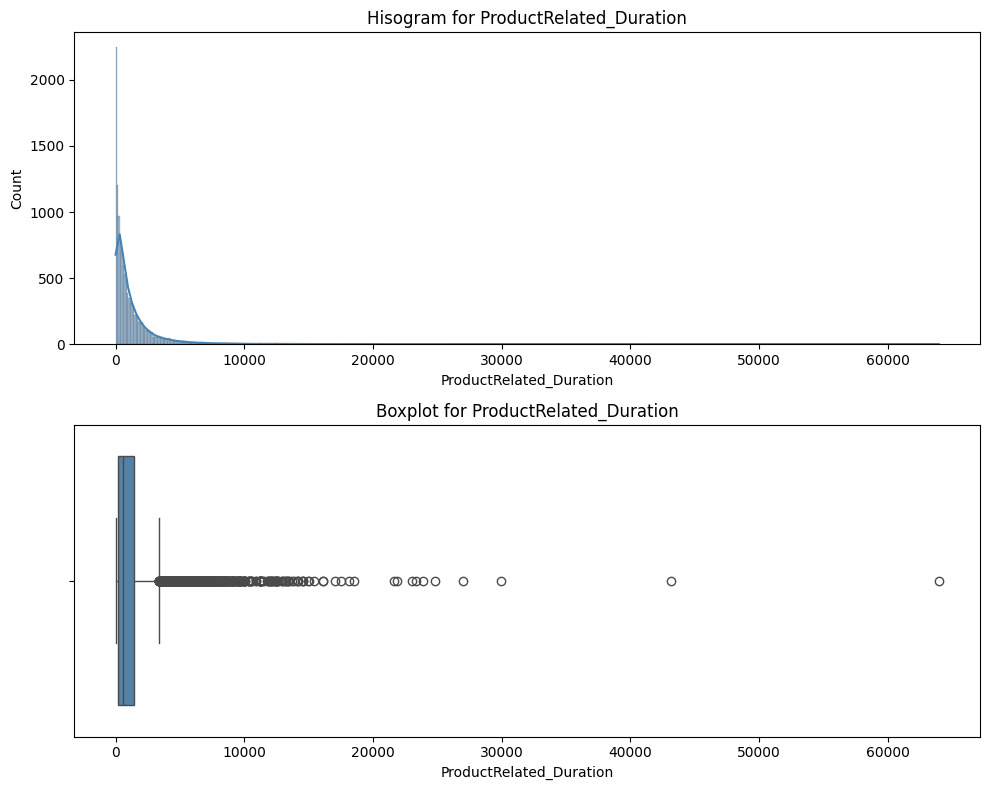



***Distribution plots for BounceRates***


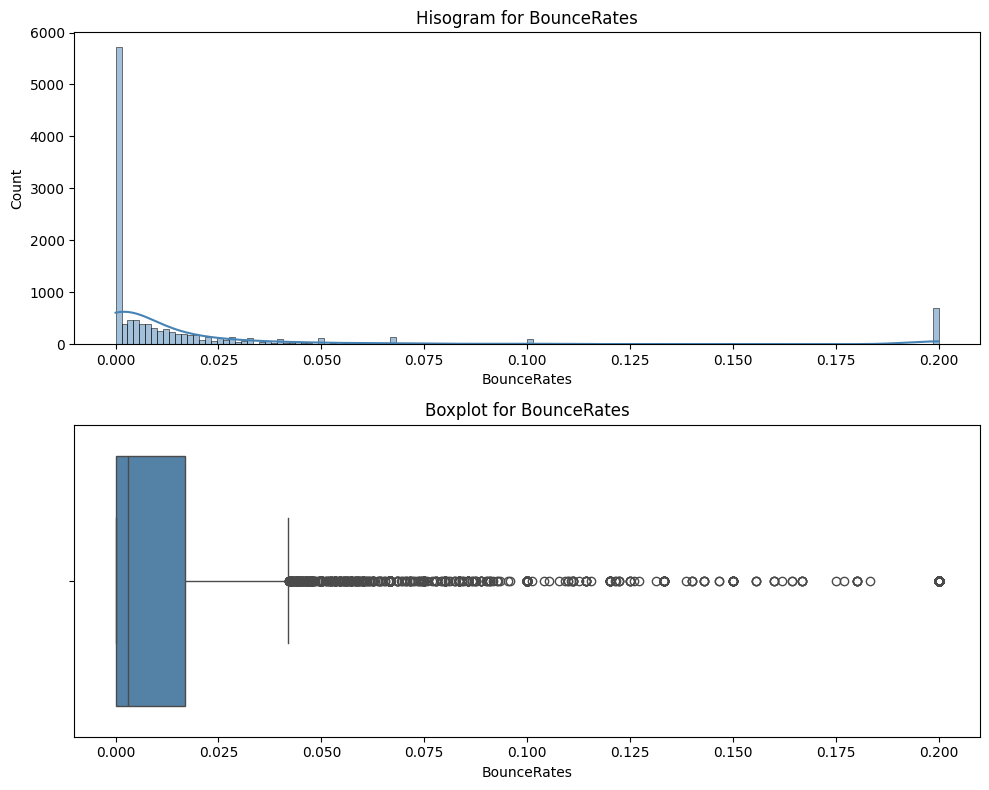



***Distribution plots for ExitRates***


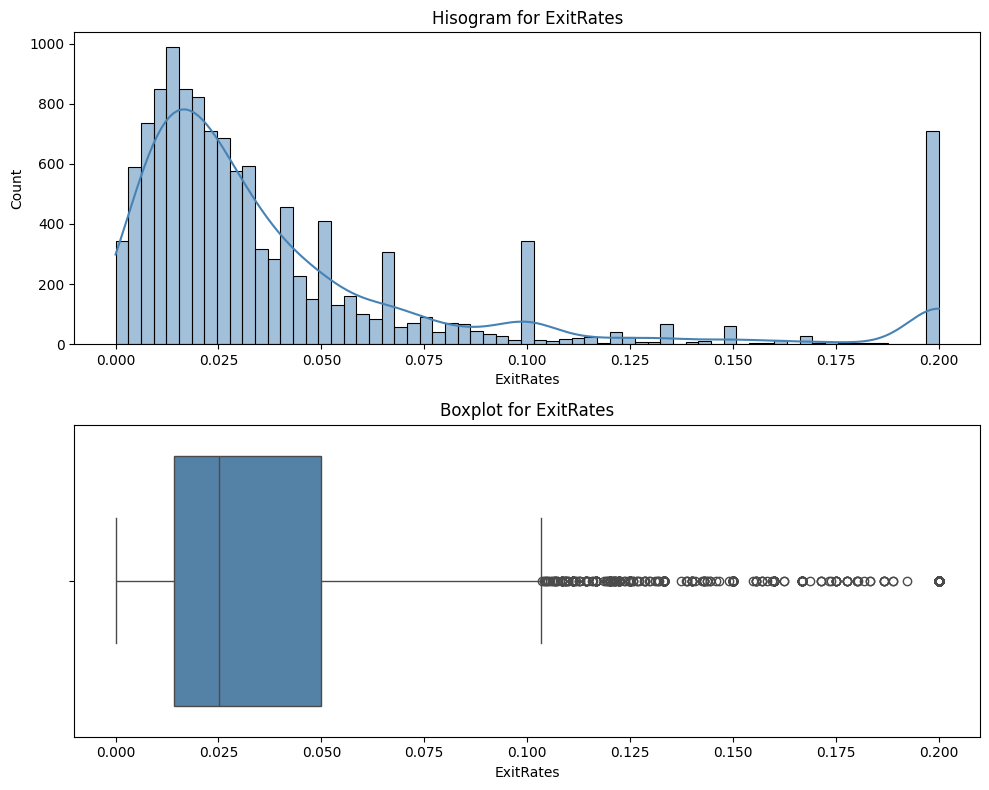



***Distribution plots for PageValues***


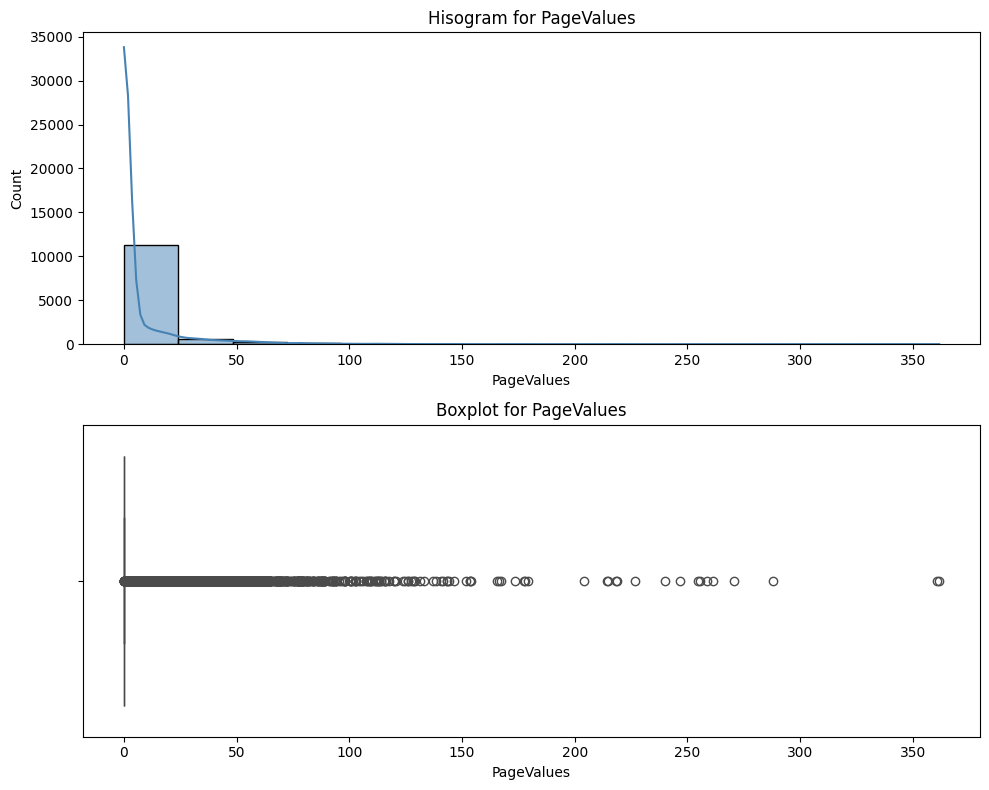



***Distribution plots for SpecialDay***


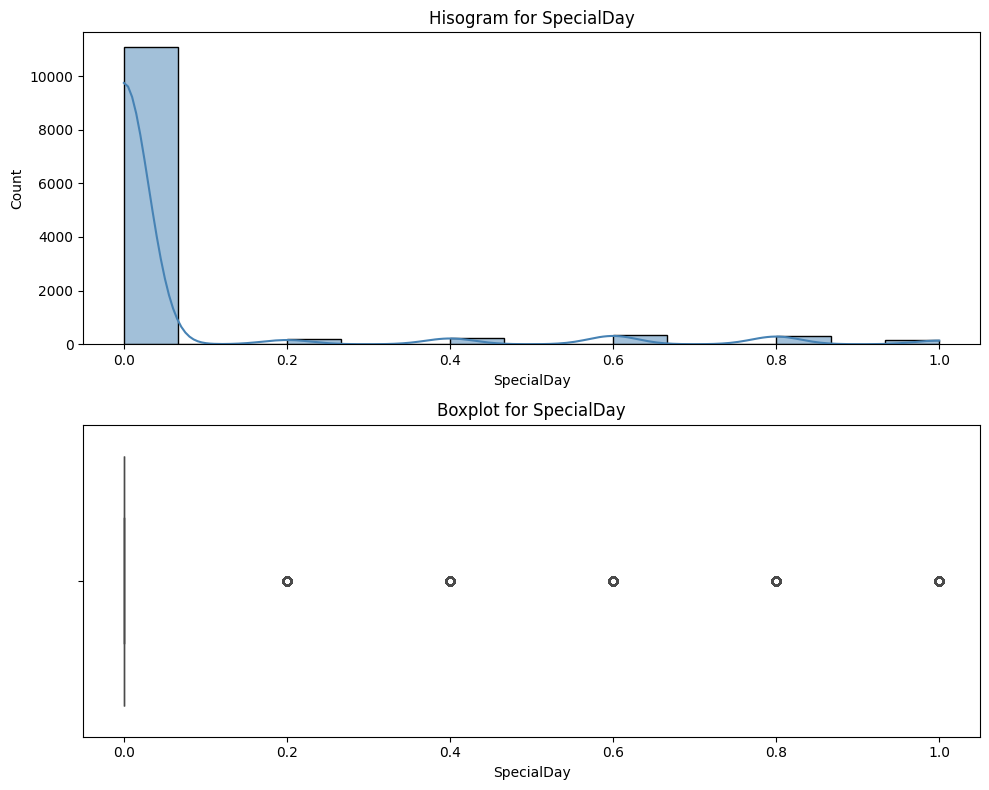

In [13]:
# update numerical columns
num_features = [col for col in numerical_features if col not in unique_cols]

# create distribution plots for numeric columns
for col in num_features:
    print(f"***Distribution plots for {col}***")
    create_histplot_and_boxplots(df, col)
    print("\n")

In [14]:
# set of features in unique_cols are actually categorical in nature
# updating the categorical features
cat_features = unique_cols + categorical_features

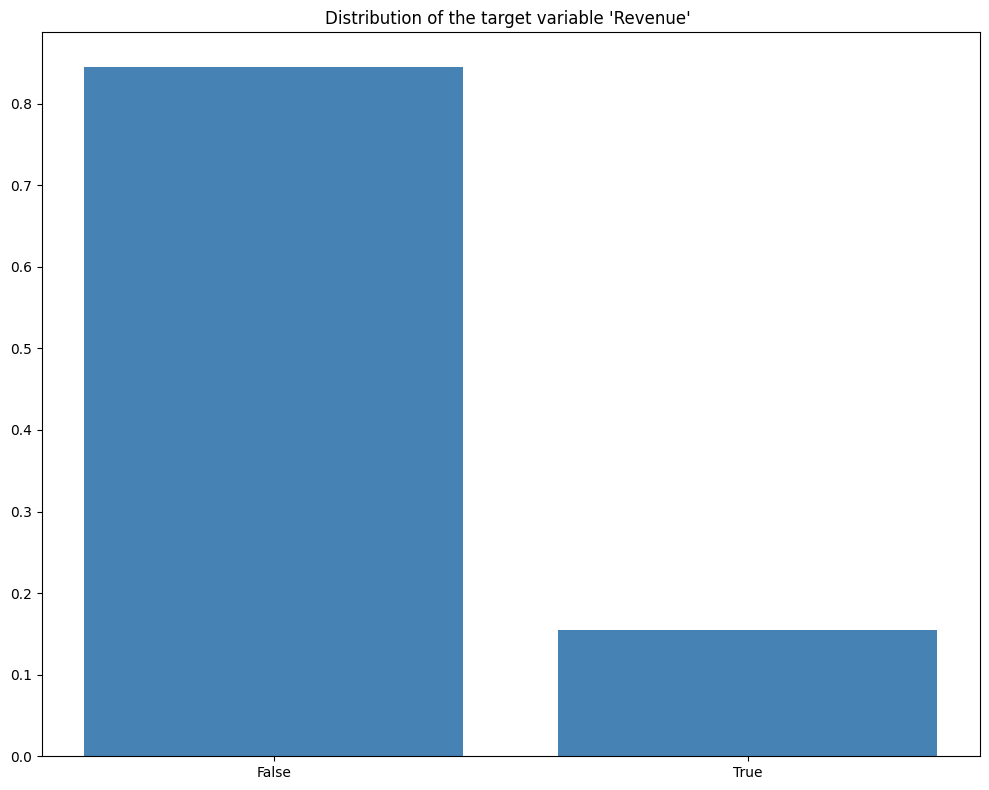

In [15]:
# next we will check the distribution for the target variable 
plt.figure(figsize=(10, 8))
counts = df[target].value_counts(normalize=True)
plt.bar(x=counts.index.astype('str'), height=counts.values, color='steelblue')
plt.title("Distribution of the target variable 'Revenue' ")
plt.tight_layout()
plt.show()

The above plot shows that the target has more than 80% observations where a purchase was not made and only ~15% of people made the purchase; thus, this dataset is highly imbalanced. Therefore, we will be focusing on precision, recall, and F1 score to measure the model's performance.

### Bivariate EDA

- Next, we will explore the relationship between the target variable and all the features:

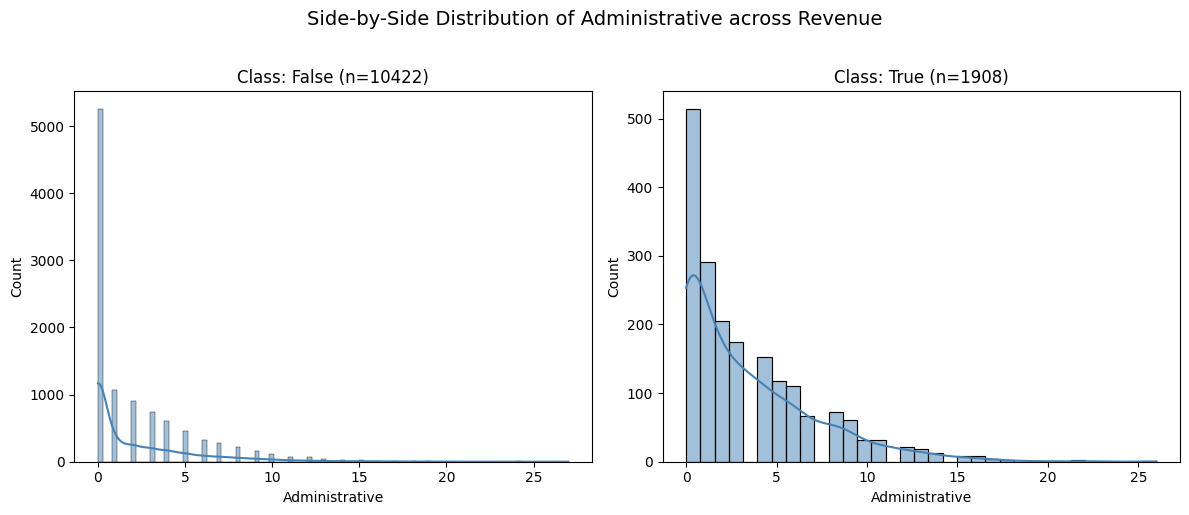

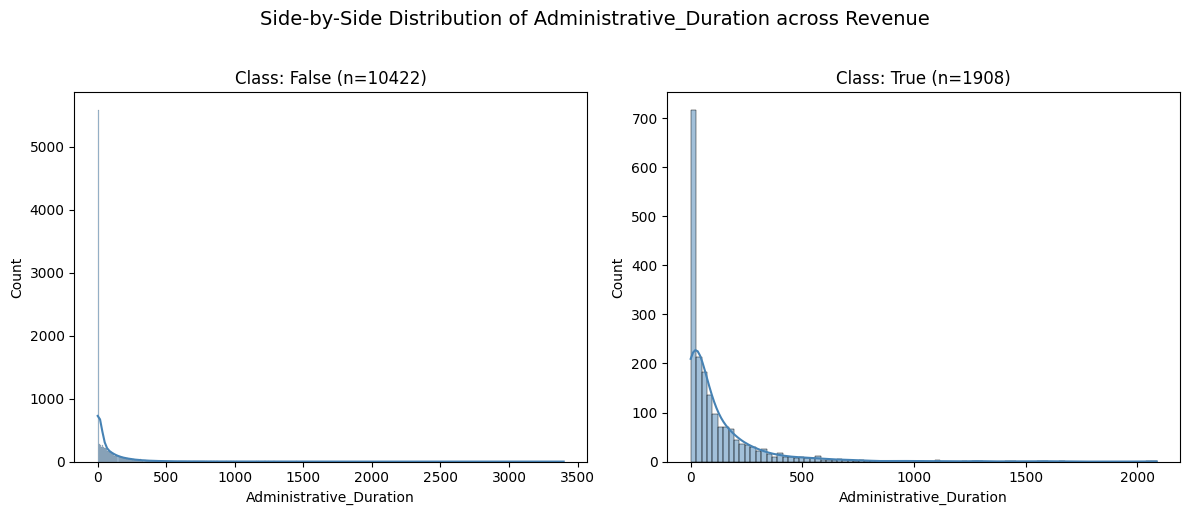

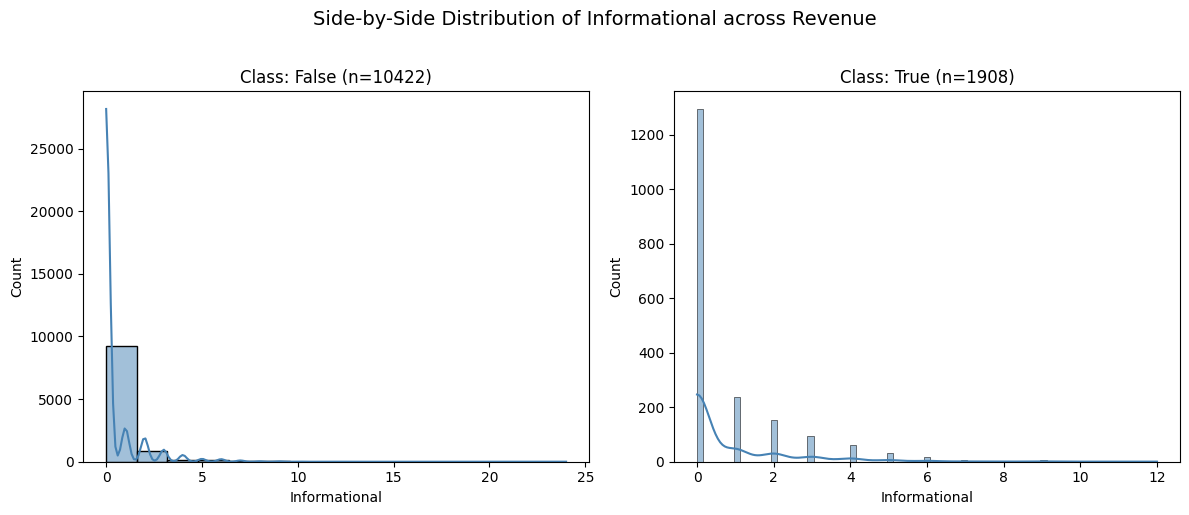

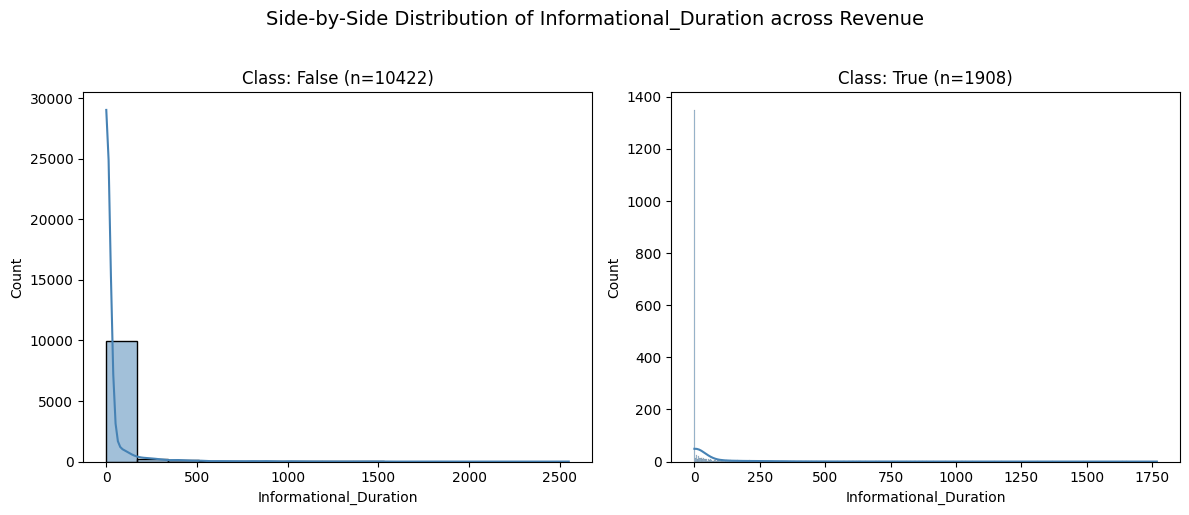

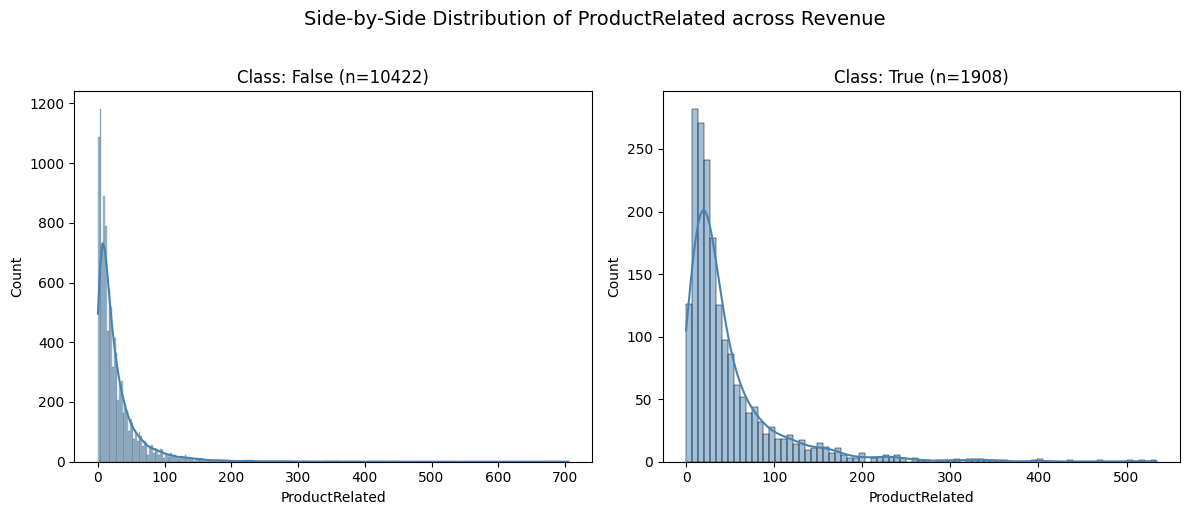

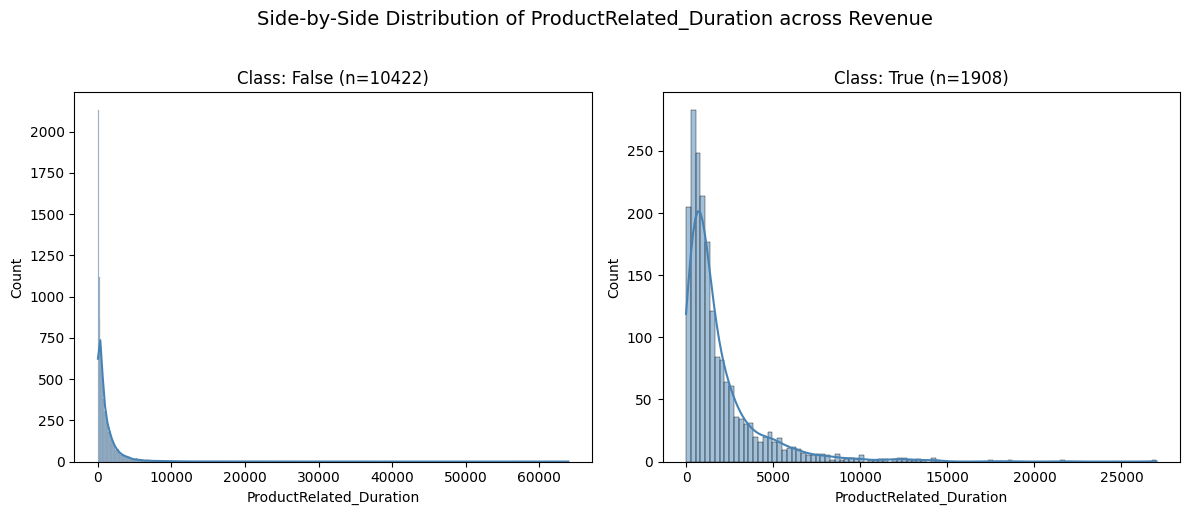

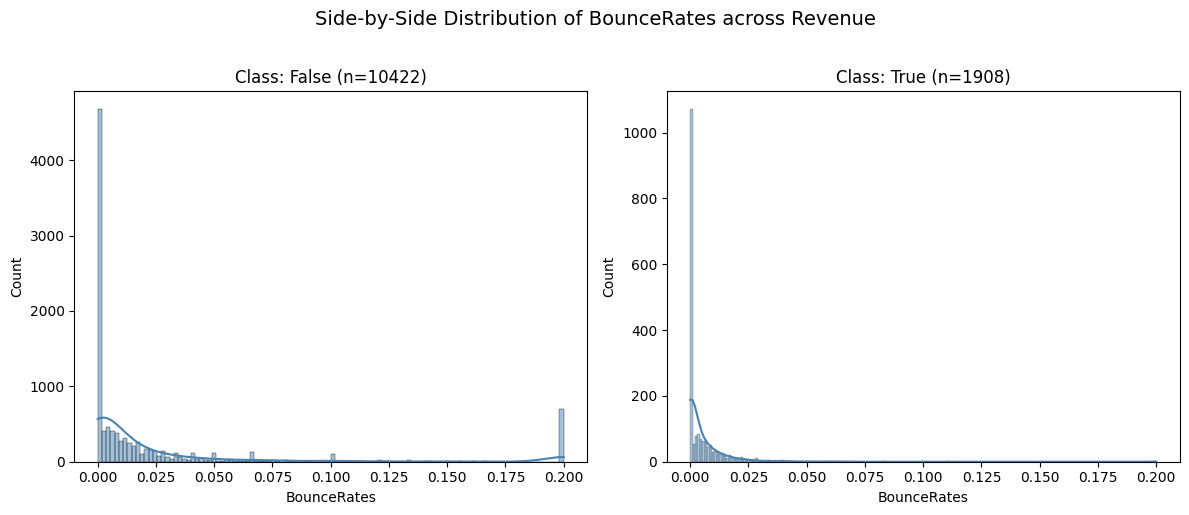

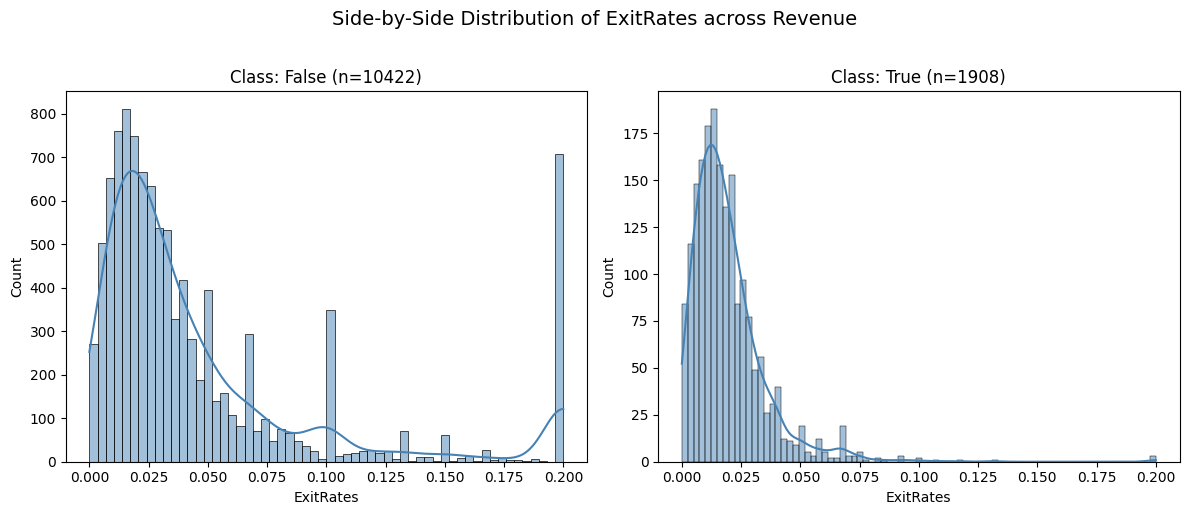

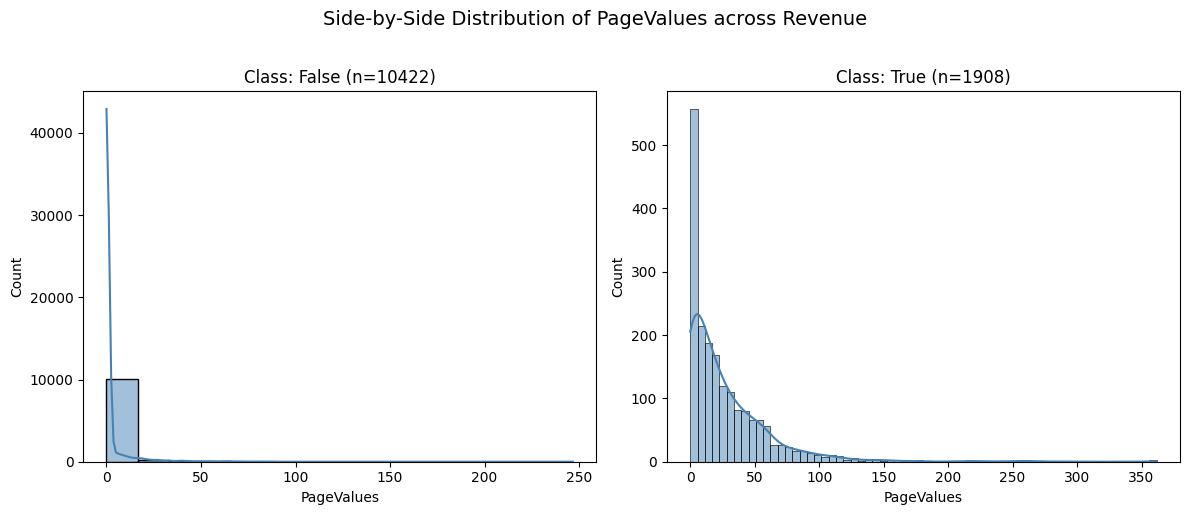

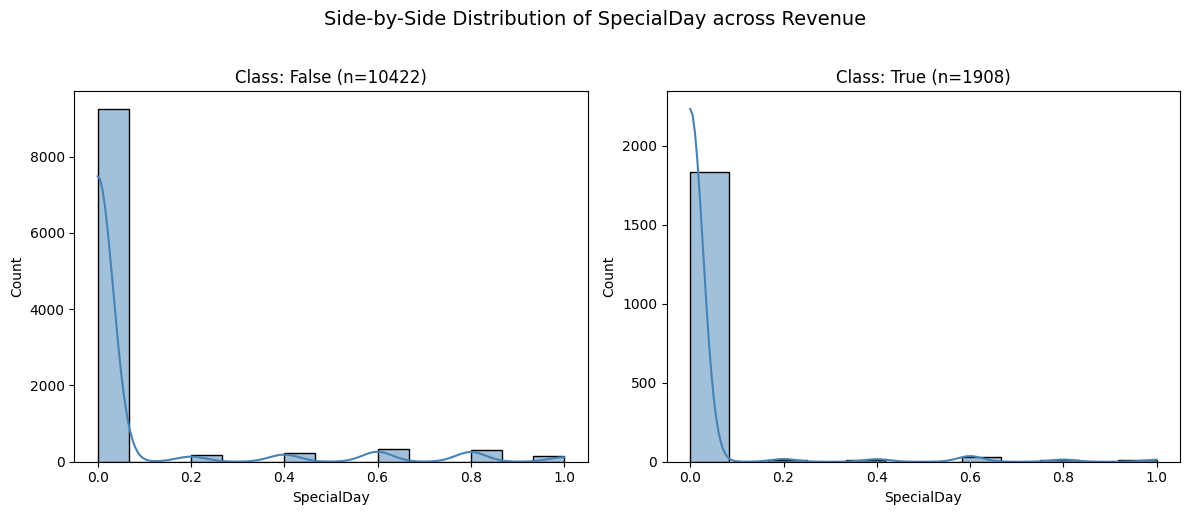

In [16]:
for feature in num_features:
    numer_vs_target_side_by_side(df, feature, target)

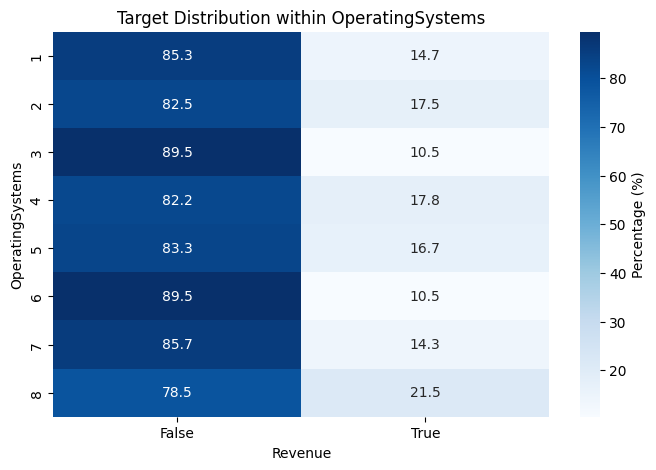

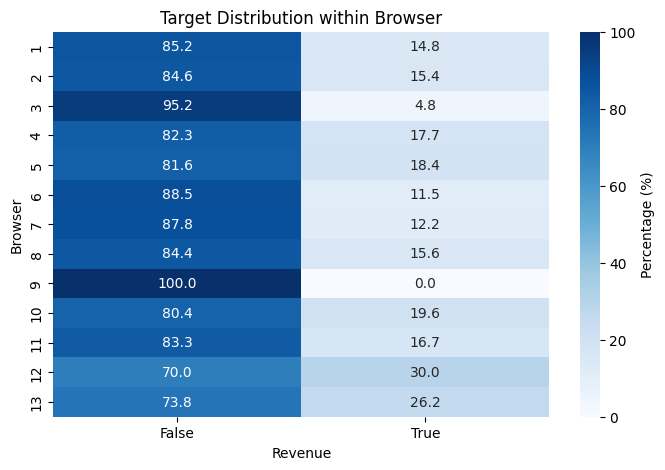

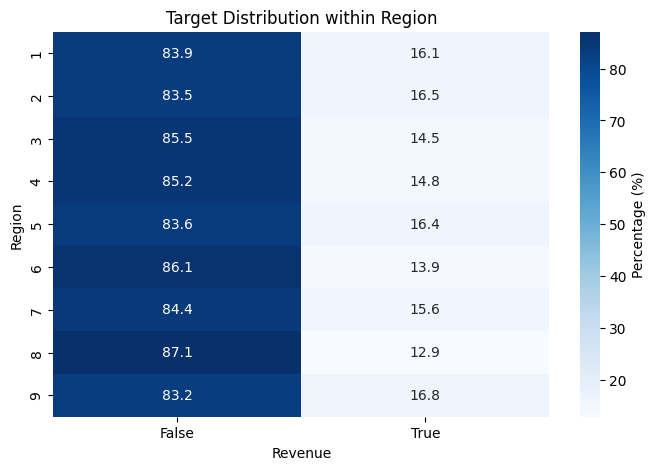

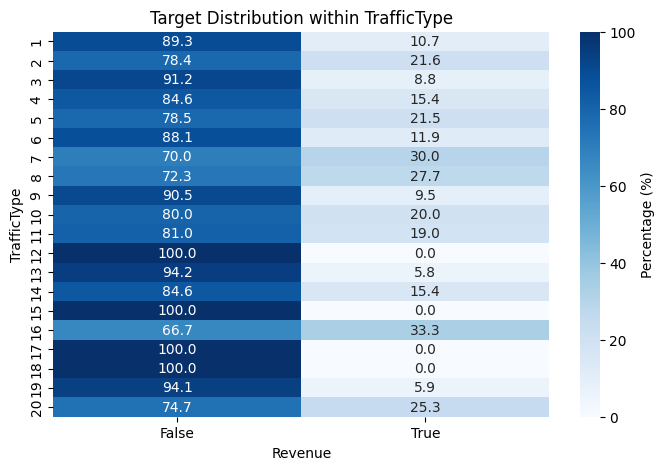

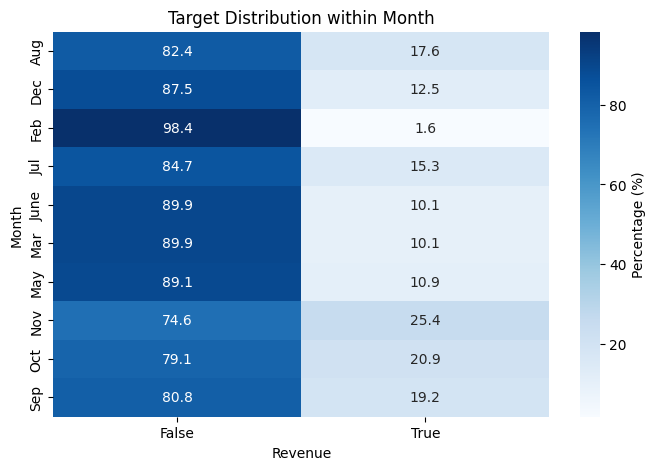

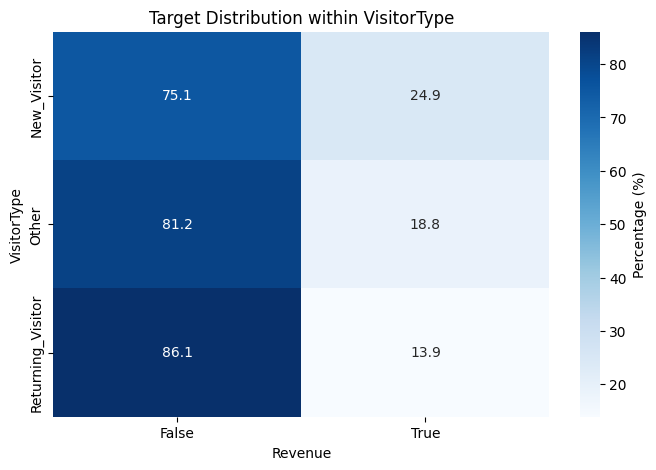

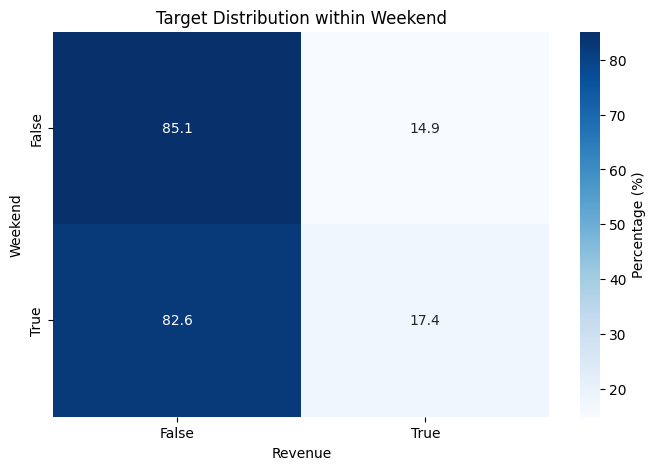

In [17]:
# create heatmaps for categorical columns
for cat_col in cat_features:
    plot_crosstab_heatmap(df, cat_col, target)

Now, we will visualize the same information using bar charts:

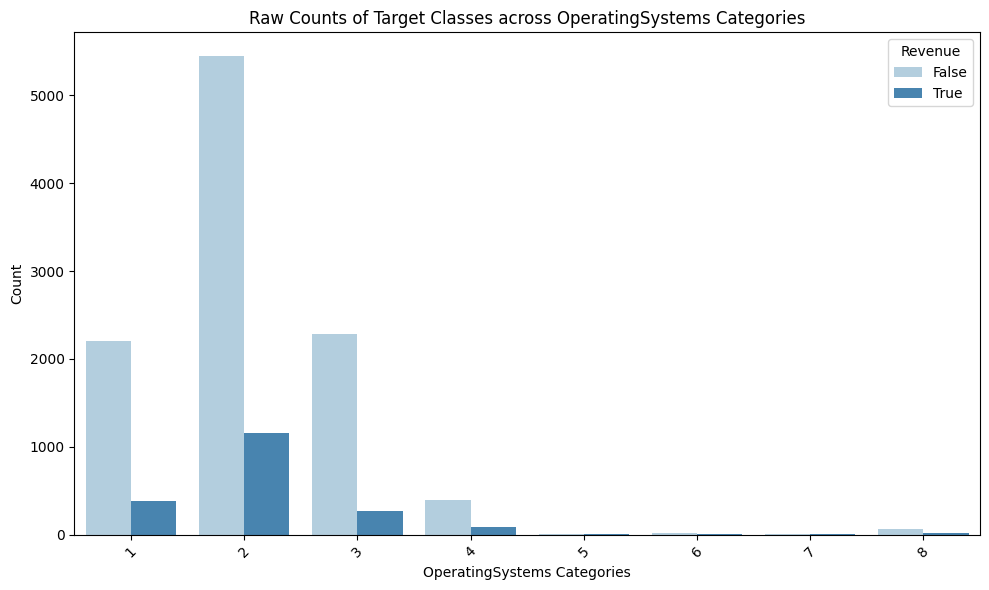

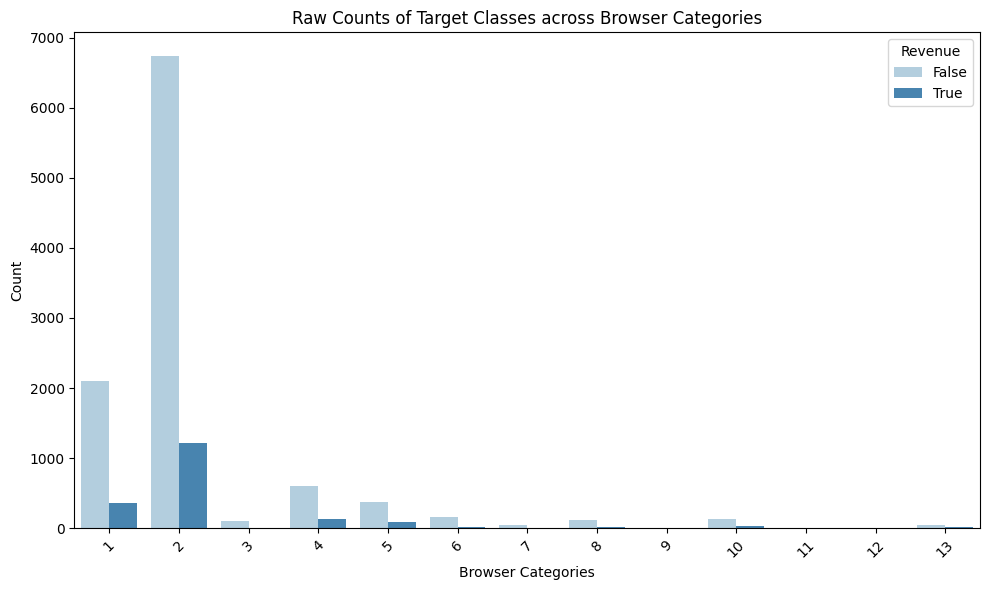

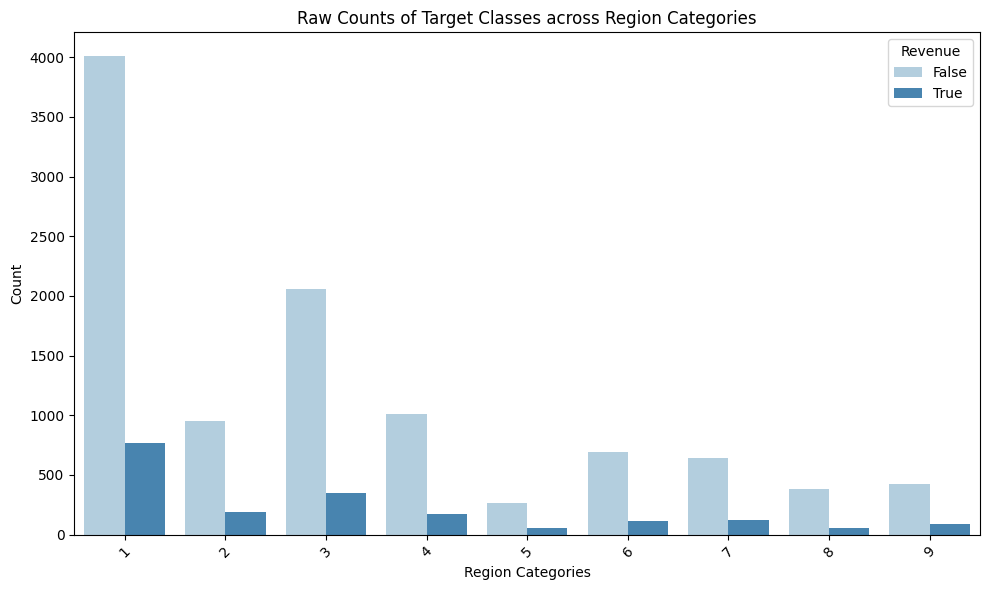

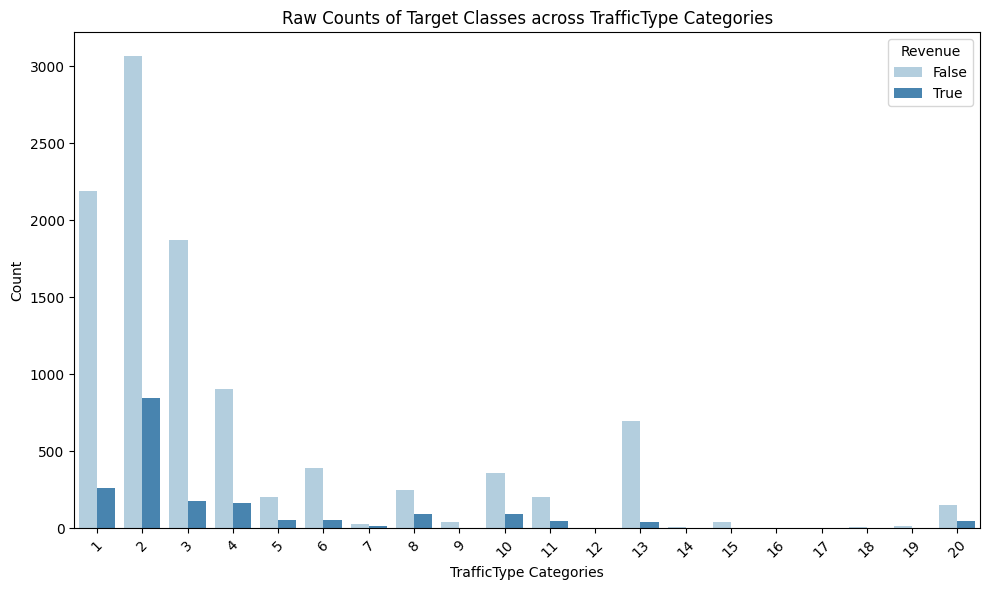

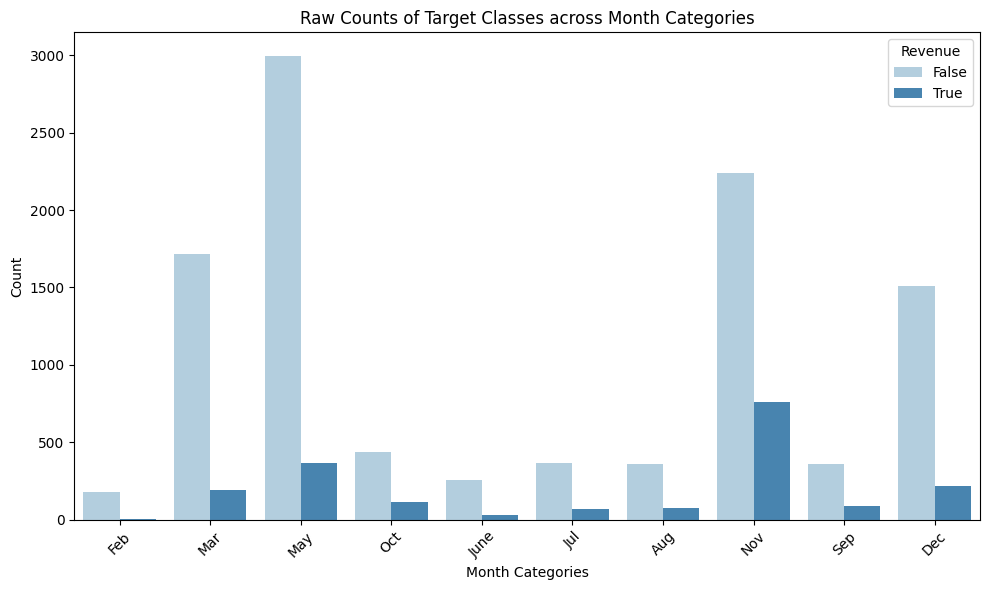

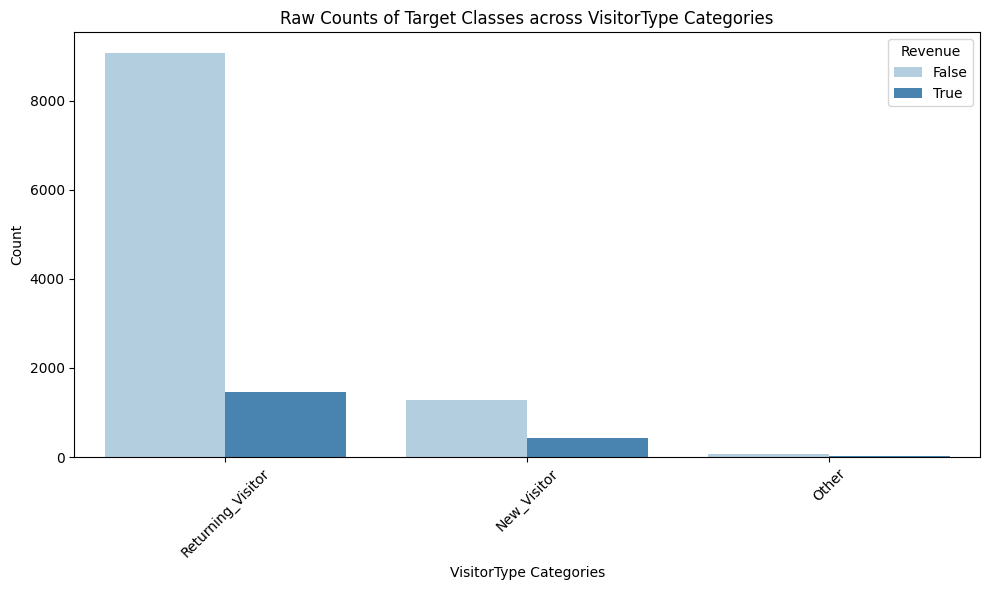

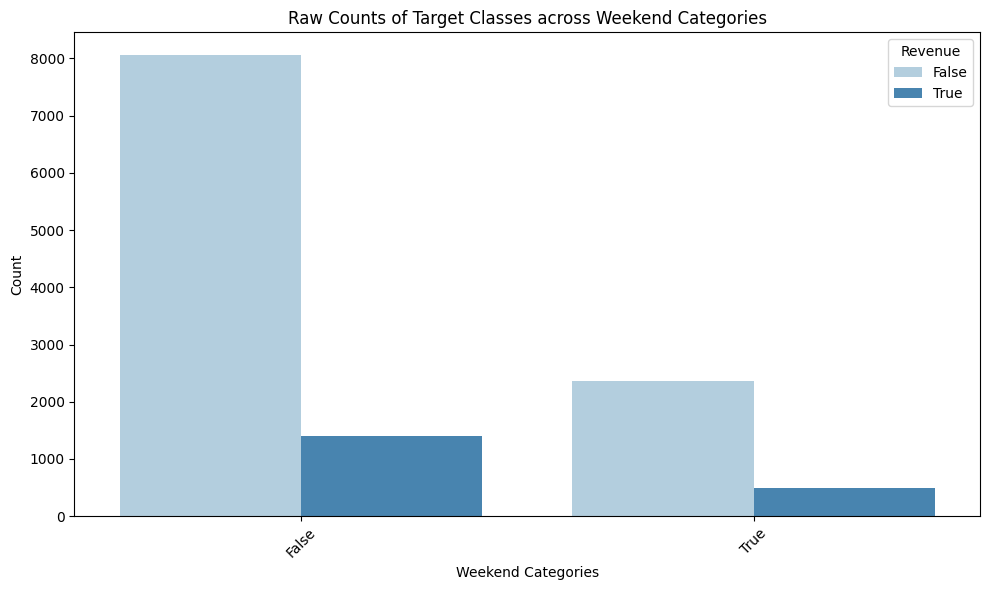

In [18]:
for cat_col in cat_features:
    target_bar_charts(df, cat_col, target)

Next, we will move towards data cleaning and transformation:

**Check missing values**: We have noted from the EDA that the dataset does not have any missing values. About the inconsisent data, it appears from the descriptive statistics of the numerical features and summary statistics of the categorical features that the dataset has reasonably consistent values.

**Duplicate values** Next, we will check if the data has any duplicate values:

In [19]:
print(f"The dataset has {int(df.duplicated().sum())} duplicate values")

The dataset has 125 duplicate values


In [66]:
df_clean = df.drop_duplicates().reset_index(drop=True)

In [21]:
print(f"The dataset has {int(df_clean.duplicated().sum())} duplicate values")

The dataset has 0 duplicate values


**Outlier Detection** We will first check if the numeric features contains any outliers and decide the handling strategy based on their number:

In [22]:
for col in num_features:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()

    print(f"IQR Range {iqr} \n"
          f"lower range {lower}\n"
          f"upper range {upper}\n"
          f"Total outliers in {col} are : {outliers}\n")

IQR Range 4.0 
lower range -6.0
upper range 10.0
Total outliers in Administrative are : 404

IQR Range 94.7 
lower range -142.05
upper range 236.75
Total outliers in Administrative_Duration are : 1149

IQR Range 0.0 
lower range 0.0
upper range 0.0
Total outliers in Informational are : 2631

IQR Range 0.0 
lower range 0.0
upper range 0.0
Total outliers in Informational_Duration are : 2405

IQR Range 30.0 
lower range -37.0
upper range 83.0
Total outliers in ProductRelated are : 1007

IQR Range 1284.154762 
lower range -1733.2321429999997
upper range 3403.3869049999994
Total outliers in ProductRelated_Duration are : 951

IQR Range 0.016666667 
lower range -0.0250000005
upper range 0.041666667500000004
Total outliers in BounceRates are : 1428

IQR Range 0.034298439 
lower range -0.0372166855
upper range 0.0999770705
Total outliers in ExitRates are : 1325

IQR Range 0.0 
lower range 0.0
upper range 0.0
Total outliers in PageValues are : 2730

IQR Range 0.0 
lower range 0.0
upper range 0.0

Based on the IQR analysis, standard statistical outlier removal is unsuitable for this web traffic dataset. Features like Informational, Informational Duration PageValues, and SpecialDay exhibit an IQR of zero due to zero-inflation, causing all non-zero interactions to be flagged as outliers. Furthermore, negative lower bounds for duration and count features are physically impossible. Because extreme values in customer behavior represent high-intent engagement rather than data corruption, retaining the raw observations preserves critical conversion signals.

 To prevent losing valuable conversion signals from power-user sessions, all feature values will be preserved as-is.

In [70]:
df_clean.to_csv("../data/clean_data.csv", index=False)

### Modeling
- We will use ensemble models like Random Forest, XGBoost, and Light GBM models as base models to generate OOF predictions.
- To accommodate the heavily skewed, zero-inflated distributions of numerical features and the multi-category cardinality of categorical features, linear and distance-based models have been excluded from the pipeline.

In [23]:
# preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (train_test_split, 
StratifiedKFold, cross_val_score, cross_validate)
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# evaluation
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
confusion_matrix, classification_report, ConfusionMatrixDisplay, fbeta_score)

In [24]:
all_models = []


rf_params = [
    {'n_estimators' : 100, 'max_depth' : 10, 'min_samples_split' : 5},
    {'n_estimators' : 300, 'max_depth' : 20, 'min_samples_split': 2},
    {'n_estimators' : 500, 'max_depth' : 30, 'min_samples_split' : 5}
]

xgb_params = [
    {'n_estimators' : 1000, 'learning_rate' : 0.03, 'max_depth' : 5},
    {'n_estimators' : 3000, 'learning_rate' : 0.01, 'max_depth' : 7},
    {'n_estimators' : 10000, 'learning_rate' : 0.001, 'max_depth' : 10}

]

lgbm_params = [
    {'learning_rate': 0.02, 'n_estimators': 3000,  'num_leaves': 63, 'max_depth': 8},
    {'learning_rate': 0.03, 'n_estimators': 2000,  'num_leaves': 31, 'max_depth': 6},
    {'learning_rate': 0.05, 'n_estimators': 1500,  'num_leaves': 15, 'max_depth': 4}
]

In [25]:
seeds = range(12)

for seed in seeds:

    for j, params in enumerate(rf_params):
        rf_model = (f"rf_{j}_{seed}", RandomForestClassifier(class_weight="balanced", random_state=seed, **params))
        all_models.append(rf_model)

    for k, params in enumerate(xgb_params):
        xgb_model = (f"xgb_{k}_{seed}", XGBClassifier(objective='binary:logistic', random_state=seed, **params))
        all_models.append(xgb_model)


    for l, params in enumerate(lgbm_params):
            lgb_model = (f"lgb_{l}_{seed}", LGBMClassifier(objective='binary', is_unbalance=True, verbosity=-1, random_state=seed, **params) )
            all_models.append(lgb_model)
                         

In [26]:
print(f"We have set up a total of {len(all_models)} models.")

We have set up a total of 108 models.


In [27]:
X = df_clean[cat_features + num_features]
y = df_clean[target].astype('int')

In [29]:
y

0        0
1        0
2        0
3        0
4        0
        ..
12325    0
12326    0
12327    0
12328    0
12329    0
Name: Revenue, Length: 12205, dtype: int64

In [30]:
def creat_oof_preds(X, y, models, cat_features, num_features):

    # Dictionary to store each model's full OOF predictions array
    oof_preds = {}

    # k-fold object for cross-validation
    skf = StratifiedKFold(shuffle=True, n_splits=5,random_state=42)


    # preprocessing pipeline
    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
                      ('num', RobustScaler(), num_features)
                     ]
    )
    
    for name, base_model in models:
        oof_model = np.zeros(len(X))

        for train_idx, val_idx in skf.split(X, y):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            
            pipeline = Pipeline(steps=
                                [('pre', preprocessor),
                                 ('model', clone(base_model))
                                ])

            pipeline.fit(X_train, y_train)
            oof_model[val_idx] = pipeline.predict_proba(X_val)[:, 1]

        oof_preds[name] = oof_model

    return oof_preds   



def get_ranked_predictions(oof_predictions, y, top_k=30, corr_threshold=0.95):

    # Step 1: Score all 108 models using F2 Score (tuning threshold)
    print(f"Scoring 108 models...")
    model_metrics = []

    # Ensure y is converted to a clean NumPy array to avoid Pandas index alignment issues
    y_arr = y.values if hasattr(y, 'values') else y
    
    
    for model, y_prob in oof_predictions.items():

        best_f2_score = 0
        best_threshold = 0.5

        for threshold in np.linspace(0.05, 0.95, 19):
            y_pred = (y_prob >= threshold).astype(int)
            f2_score =  fbeta_score(y.values, y_pred, beta=2, zero_division=0)

            if f2_score > best_f2_score:
                best_f2_score = f2_score
                best_threshold = threshold

        model_metrics.append({
                "model_name": model,
                "f2_score" : best_f2_score,
                "threshold": best_threshold
        })

    df_scores = \
    pd.DataFrame(model_metrics).sort_values(by=["f2_score"], ascending=False)

    # Step 2: Filter out redundant (highly correlated) models
    print("Filtering for prediction diversity...")
    df_oofs = pd.DataFrame(oof_predictions)
    selected_models = []


    for model_name in df_scores["model_name"]:

        if len(selected_models) >= top_k:
            break

        if not selected_models:
            selected_models.append(model_name)

        else:
            corr = df_oofs[selected_models].corrwith(df_oofs[model_name])

            if corr.max() < corr_threshold:
                selected_models.append(model_name)


    print(f"Selected {len(selected_models)} diverse top-performing models!")

    ranked_oofs = df_oofs[selected_models].rank(pct=True)
    final_blend_oof = ranked_oofs.mean(axis=1)


    return selected_models, final_blend_oof, df_scores 

In [31]:
oof_predictioins = creat_oof_preds(X, y, all_models, cat_features, num_features)

In [32]:
len(oof_predictioins)

108

In [39]:
final_models, final_blend_oofs, f2_scores = get_ranked_predictions(oof_predictioins, y, corr_threshold=0.97)

Scoring 108 models...
Filtering for prediction diversity...
Selected 6 diverse top-performing models!


In [54]:
final_models, final_blend_oofs, f2_scores = get_ranked_predictions(oof_predictioins, y, corr_threshold=0.98)

Scoring 108 models...
Filtering for prediction diversity...
Selected 7 diverse top-performing models!


In [55]:
final_models

['rf_2_5', 'rf_0_1', 'xgb_0_8', 'xgb_2_2', 'lgb_1_8', 'lgb_2_0', 'lgb_0_9']

In [56]:
f2_scores

,model_name,f2_score,threshold
47,rf_2_5,0.762003,0.20
56,rf_2_6,0.760830,0.20
65,rf_2_7,0.760144,0.20
11,rf_2_1,0.760126,0.20
83,rf_2_9,0.760000,0.20
...,...,...,...
69,lgb_0_7,0.730862,0.05
6,lgb_0_0,0.730862,0.05
15,lgb_0_1,0.730862,0.05
78,lgb_0_8,0.730862,0.05


In [74]:
print("Here are the decision thresholds for final models:")
display(pd.DataFrame(f2_scores.loc[f2_scores['model_name'].isin(final_models), 'threshold']).reset_index(drop=True))

Here are the decision thresholds for final models:


,threshold
0,0.20
1,0.40
2,0.15
3,0.10
4,0.10
5,0.25
6,0.05


In [58]:
# Tuning a SINGLE threshold on the final rank-averaged output
best_blend_f2 = 0.0
best_blend_thresh = 0.5
y_arr = y.values if hasattr(y, 'values') else y

for thresh in np.linspace(0.05, 0.95, 91):  # Fine grid (steps of 0.01)
    preds = (final_blend_oofs >= thresh).astype(int)
    score = fbeta_score(y_arr, preds, beta=2, zero_division=0)
    
    if score > best_blend_f2:
        best_blend_f2 = score
        best_blend_thresh = thresh

print(f"Top 6 Ensemble OOF F2 Score: {best_blend_f2:.4f}")
print(f"Optimal Blended Threshold: {best_blend_thresh:.2f}")

Top 6 Ensemble OOF F2 Score: 0.7575
Optimal Blended Threshold: 0.73


In [59]:
y_pred_final = (final_blend_oofs >= best_blend_thresh).astype(int)

In [60]:
accuracy_score(y_arr, y_pred_final)

0.8526833265055305

In [61]:
precision_score(y_arr, y_pred_final)

0.5174050632911392

In [62]:
recall_score(y_arr, y_pred_final)

0.8569182389937107

In [53]:
fbeta_score(y, y_pred_final, beta=2, zero_division=0)

0.7573343331146312

### Here is the final classification report of our Ensemble Model:

In [65]:
print(classification_report(y, y_pred_final))

              precision    recall  f1-score   support

           0       0.97      0.85      0.91     10297
           1       0.52      0.86      0.65      1908

    accuracy                           0.85     12205
   macro avg       0.74      0.85      0.78     12205
weighted avg       0.90      0.85      0.87     12205

